In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, BertTokenizerFast, DistilBertTokenizerFast, AutoTokenizer, RobertaForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import os
import shap
import spacy
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from collections import defaultdict, Counter
import random
import pickle
import re

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
model_name = "roberta"

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [ ]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df = pd.read_csv('../data/combined_letters_degendered.csv')

# Create Training and Test Sets

In [ ]:
train_text, temp_text, train_labels, temp_labels = train_test_split(df['full_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("../saved_models/final_roberta_degendered_model")

model = RobertaForSequenceClassification.from_pretrained("../saved_models/final_roberta_degendered_model")

In [ ]:
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt",
    max_length=512
)

tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt",
    max_length=512
)

tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt",
    max_length=512
)

In [ ]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

/tmp/ipython-input-2686642901.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids'])
/tmp/ipython-input-2686642901.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask'])
/tmp/ipython-input-2686642901.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val['input_ids'])
/tmp/ipython-input-2686642901.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or 

# Test Model

In [ ]:
model.to(device)

model.eval()

test_data = TensorDataset(test_seq, test_mask, test_y)
test_dataloader = DataLoader(test_data, batch_size=32)  # adjust batch size as needed

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        sent_id, mask, labels = [b.to(device) for b in batch]
        outputs = model(sent_id, mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('Test Classification Report:\n', classification_report(all_labels, all_preds))
print('Test Confusion Matrix:\n', confusion_matrix(all_labels, all_preds))

Test Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.33      0.36       279
           1       0.72      0.76      0.74       620

    accuracy                           0.63       899
   macro avg       0.55      0.55      0.55       899
weighted avg       0.61      0.63      0.62       899

Test Confusion Matrix:
 [[ 93 186]
 [149 471]]


# SHAP

In [ ]:
tokenizer.bos_token = tokenizer.cls_token
tokenizer.eos_token = tokenizer.sep_token
tokenizer.add_special_tokens({"bos_token": tokenizer.bos_token, "eos_token": tokenizer.eos_token})

def f(x):
    encoded_inputs = [
        tokenizer.encode_plus(v, max_length=512, padding="max_length", truncation=True, return_tensors="pt")
        for v in x
    ]
    input_ids = torch.cat([e['input_ids'] for e in encoded_inputs], dim=0).to(device)
    attention_masks = torch.cat([e['attention_mask'] for e in encoded_inputs], dim=0).to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_masks)
        logits = outputs.logits
        probs = torch.exp(logits).cpu().numpy()

    return probs[:, 1]  # probability of class 1

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)

sample_texts = pd.concat([test_text, val_text, train_text]).dropna().astype(str).sample(n=10, random_state=42).tolist()
shap_values = explainer(sample_texts, fixed_context=1)

Token indices sequence length is longer than the specified maximum sequence length for this model (524 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:40<00:58,  8.30s/it]

...

PartitionExplainer explainer:  90%|█████████ | 9/10 [02:12<00:14, 14.42s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [02:25<00:00, 13.93s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [02:41, 16.14s/it]


# POS Analysis

In [ ]:
# # save both shap_values and sample_texts together
# save_path = f"../cleaned_data/shap_values_pkl/shap_bundle_{model_name}.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(
#         {
#             "sample_texts": sample_texts,
#             "shap_values": shap_values,
#         },
#         f,
#     )

In [ ]:
# load saved bundle
load_path = f"../cleaned_data/shap_values_pkl/shap_bundle_{model_name}.pkl"
with open(load_path, "rb") as f:
    bundle = pickle.load(f)

In [ ]:
sample_texts = bundle["sample_texts"]
shap_values = bundle["shap_values"]

In [ ]:
def words_with_scores_for_example(text, scores, tokenizer):
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=True,
        truncation=True,
        max_length=512
    )

    hf_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])

    word_ids = enc.word_ids()
    offsets = enc["offset_mapping"]

    L = min(len(scores), len(word_ids))
    scores  = scores[:L]
    word_ids = word_ids[:L]
    offsets  = offsets[:L]

    assert len(scores) == len(hf_tokens), "Mismatch between SHAP scores and tokenizer tokens"

    by_word = {}
    for wid, (st, en), sc in zip(word_ids, offsets, scores):
        if wid is None or st == en:
            continue
        if wid not in by_word:
            by_word[wid] = [st, en, float(sc)]
        else:
            by_word[wid][1] = en
            by_word[wid][2] += float(sc)

    words = []
    for wid, (st, en, ssum) in by_word.items():
        w = text[st:en]
        w_norm = re.sub(r"^\W+|\W+$", "", w).lower()
        if w_norm:
            words.append((w_norm, ssum))
    return words


In [ ]:
# Step 2: Aggregate subwords into whole words using tokenizer word alignment
word_shap = defaultdict(list)
for text, token_scores in zip(sample_texts, shap_values.values):
    words = words_with_scores_for_example(text, token_scores, tokenizer)
    for w, sc in words:
        word_shap[w].append(sc)

# Step 3: Build dataframe
token_data = [(w, len(vals), float(np.mean(vals))) for w, vals in word_shap.items()]
df_token_stats = pd.DataFrame(token_data, columns=["token", "count", "mean_shap"])
df_token_stats["direction"] = np.where(df_token_stats["mean_shap"] > 0, "Male", "Female")

In [ ]:
import spacy
import pandas as pd
from collections import defaultdict

# Step 2: Filter tokens that appear fewer than min_count times
min_count = 1
df_filtered = df_token_stats[df_token_stats["count"] >= min_count].copy()

# Step 3: POS tagging
nlp = spacy.load("en_core_web_sm")
docs = list(nlp.pipe(df_filtered["token"].tolist(), batch_size=1000))

# Step 4: Attach POS to the filtered dataframe
pos_tags = []
for doc in docs:
    if len(doc) == 0:
        pos_tags.append(None)
    else:
        tok = doc[0]
        if tok.is_alpha and not tok.is_stop:
            pos_tags.append(tok.pos_)
        else:
            pos_tags.append(None)

df_filtered["pos"] = pos_tags

# Step 5: Keep only adjectives, nouns, and verbs
df_filtered = df_filtered[df_filtered["pos"].isin({"ADJ", "NOUN", "VERB"})].copy()

In [ ]:
df_filtered
# df_filtered.to_csv(f"../cleaned_data/shap_tokens/df_shap_{model_name}.csv", index=False)

,token,count,mean_shap,direction,pos
3,pleasure,7,0.008063,Male,NOUN
5,write,4,-0.001668,Female,VERB
8,letter,5,0.018300,Male,NOUN
10,recommendation,5,0.034012,Male,NOUN
17,support,10,-0.023689,Female,VERB
...,...,...,...,...,...
817,start,1,0.108553,Male,VERB
818,story,1,0.040563,Male,NOUN
819,proud,1,-0.021041,Female,ADJ
820,taking,1,0.020425,Male,VERB


In [ ]:
# Step 6: Function to get top N tokens by POS and direction
def get_top(df, pos, direction, n=10):
    subset = df[(df["pos"] == pos) & (df["direction"] == direction)]
    return subset.sort_values("mean_shap", ascending=(direction == "Female")).head(n)

# Step 7: Get top tokens
adj_male = get_top(df_filtered, "ADJ", "Male")
adj_female = get_top(df_filtered, "ADJ", "Female")
noun_male = get_top(df_filtered, "NOUN", "Male")
noun_female = get_top(df_filtered, "NOUN", "Female")
verb_male = get_top(df_filtered, "VERB", "Male")
verb_female = get_top(df_filtered, "VERB", "Female")

# Step 8: Combine for final token list
all_tokens = pd.concat([
    adj_male["token"], adj_female["token"],
    noun_male["token"], noun_female["token"],
    verb_male["token"], verb_female["token"]
], ignore_index=True)



In [ ]:
all_tokens

# Optional: save if needed
# all_tokens.to_csv(f"../cleaned_data/shap_tokens/top_tokens_shap_{model_name}.csv", index=False)

,token
0,reliable
1,teachable
2,respectful
3,dependable
4,conscientious
5,effective
6,educational
7,humble
8,past
9,academic


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_shap_by_pos(df, pos_tag, top_n=10, save_path=None):
    subset = df[df["pos"] == pos_tag]

    # Get top N for each direction
    top_male = subset[subset["direction"] == "Male"].nlargest(top_n, "mean_shap")
    top_female = subset[subset["direction"] == "Female"].nsmallest(top_n, "mean_shap")

    # Combine and label
    top = pd.concat([top_female, top_male])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x="mean_shap",
        y="token",
        hue="direction",
        dodge=False,
        palette={"Male": "indianred", "Female": "steelblue"}
    )

    plt.title(f"Top SHAP Tokens for POS = {pos_tag}", fontsize=20)
    plt.xlabel("Mean SHAP Value", fontsize=18)
    plt.ylabel("Token", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title="Direction", fontsize=16, title_fontsize=17)
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return top_male, top_female


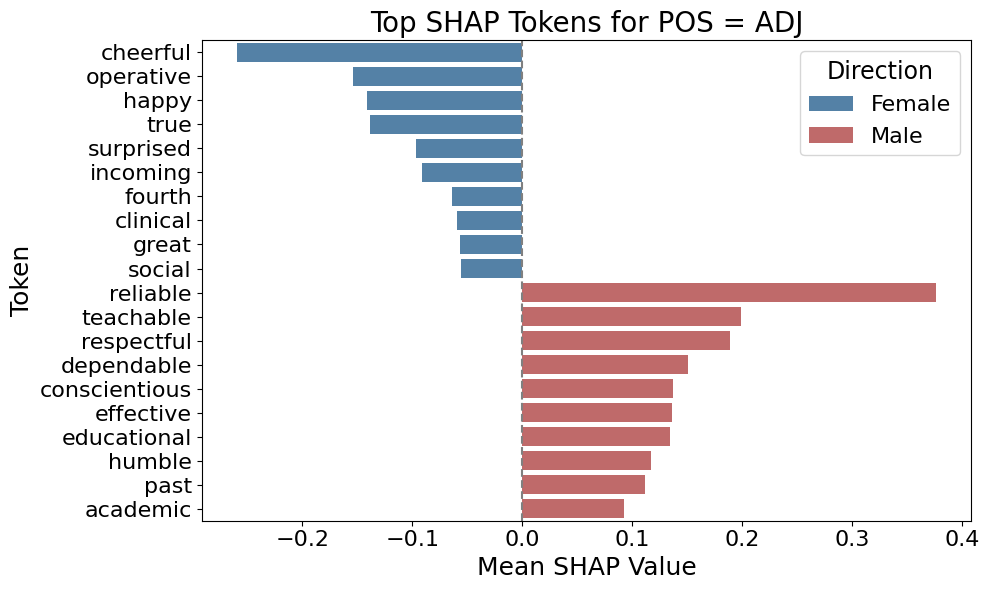

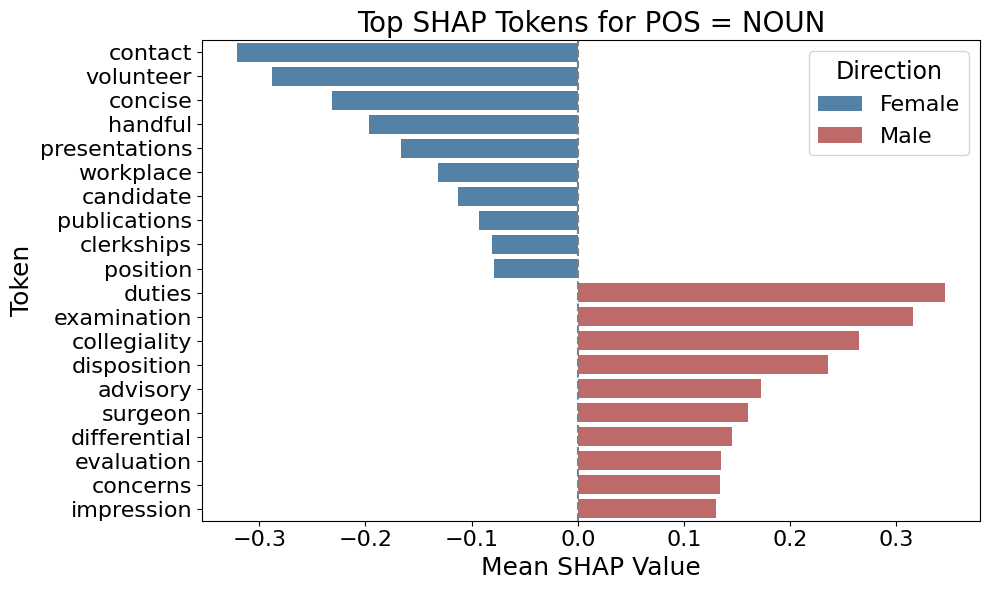

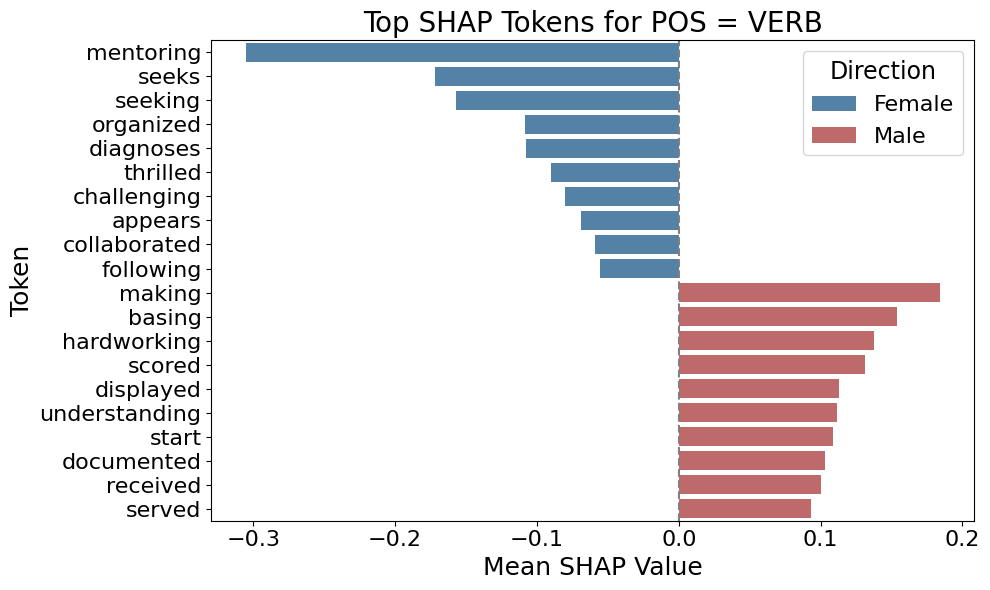

In [ ]:
# adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10, save_path=f'../cleaned_figures/{model_name}_adj_shap_chart.png')
# noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10, save_path=f'../cleaned_figures/{model_name}_noun_shap_chart.png')
# verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10, save_path=f'../cleaned_figures/{model_name}_verb_shap_chart.png')

adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10)
noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10)
verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10)



# Create Dataset With Implicit Gendered Tokens Removed - SHAP

In [ ]:
all_tokens

,token
0,reliable
1,teachable
2,respectful
3,dependable
4,conscientious
5,effective
6,educational
7,humble
8,past
9,academic


In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

# Load RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained("../saved_models/final_roberta_degendered_model")
mask_token = tokenizer.mask_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


In [ ]:
df = pd.read_csv('../data/combined_letters_degendered.csv')
# Apply the masking
df["full_text"] = df["full_text"].apply(mask_text)

In [ ]:
# df.to_csv(f"../cleaned_data/implicit_degendered_data/combined_letters_degendered_{model_name}_shap_tokens_removed.csv", index=False)


# Create Dataset With Implicit Gendered Tokens Removed - TFIDF

In [ ]:
all_tokens_df = pd.read_csv('../data/top_tokens_tfidf.csv')
all_tokens = all_tokens_df['token']

In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("../saved_models/final_roberta_degendered_model")
mask_token = tokenizer.mask_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


In [ ]:
df = pd.read_csv('../data/combined_letters_degendered.csv')
# Apply the masking
df["full_text"] = df["full_text"].apply(mask_text)

In [ ]:
df

,full_text,label
0,it is my pleasure to write a letter of recomme...,0
1,i am pleased to highly recommend <mask> for ...,0
2,i am writing this letter in <mask> of <mask...,0
3,<mask> <mask> recently <mask> d an <mask...,0
4,it is my pleasure to recommend dr. <mask> fo...,0
...,...,...
8982,it is with pleasure that i recommend first_nam...,0
8983,we are very pleased to write this letter based...,0
8984,i am writing this letter of recommendation for...,1
8985,it is my pleasure to write first_name <mask> ...,1


In [ ]:
# df.to_csv(f"../cleaned_data/implicit_degendered_data/combined_letters_degendered_{model_name}_tfidf_tokens_removed.csv", index=False)
